In [40]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [41]:
import sys
sys.path.append('..')

In [42]:
from Stuff.DataPrep.DataPrep import DataPrep
from Constants import DATA_PREP_BINARY_ALL_FILE

data_prep = DataPrep.Load_From_File("../" + DATA_PREP_BINARY_ALL_FILE)

In [ ]:
from Constants import db
from DBTypes import *
from PitchDBTypes import *

cursor = db.cursor()
pitch = DB_PitchStatcast.Select_From_DB(
    cursor=cursor,
    conditional="WHERE GameId=? AND PitchId=?",
    values=(632285, 3)
)[0]

In [64]:
import copy

x_range = [x / 10 for x in range(-30, 31)]
z_range = [z / 10 for z in range(5, 46)]

pitches = []
xs = []
zs = []
for x in x_range:
    for z in z_range:
        p = copy.deepcopy(pitch)
        p.pX = x
        p.pZ = z
        pitches.append(p)
        xs.append(x)
        zs.append(z)

In [65]:
from Stuff.Model.PitchModel import PitchModel
from Constants import device
from Stuff.Model.PitchModel import *

args = DEFAULT_COMBINED_SWINGRESULTS_ARGS
network = PitchModel(args=args, data_prep=data_prep).to(device)

opva_list = network.GetPitchOutput(data_prep, "../Models/", pitches)

In [66]:
runExpectancyMatrix = DB_RunExpectancyMatrix.Select_From_DB(
    cursor=cursor,
    conditional="WHERE Year=? AND CountBalls=? AND CountStrikes=?",
    values=(pitch.Year, pitch.CountBalls, pitch.CountStrike)
)

valueBall = [x.DeltaRuns for x in runExpectancyMatrix if x.Result == 4][0]
valueStrike = [x.DeltaRuns for x in runExpectancyMatrix if x.Result == 1][0]
valueFoul = [x.DeltaRuns for x in runExpectancyMatrix if x.Result == 3][0]
valueHBP = [x.DeltaRuns for x in runExpectancyMatrix if x.Result == 6][0]

print(valueBall, valueStrike, valueFoul, valueHBP)

0.035410620272159576 -0.06782399863004684 -0.06782399863004684 0.39219847321510315


In [67]:
def GetOpvaValue(opva_list : list[DB_Output_PitchValueAggregation]) -> list[float]:
    values = []
    
    for opva in opva_list:
        pitchValue = 0

        pitchValue += opva.combinedBall * valueBall
        pitchValue += (opva.combinedCalledStrike + (opva.combinedSwing * opva.combinedWhiff)) * valueStrike
        pitchValue += (opva.combinedSwing * opva.combinedFoul) * valueFoul
        pitchValue += opva.combinedHBP * valueHBP
        pitchValue += opva.combinedSwing * opva.combinedInPlay * opva.combinedInPlayExpected
        values.append(pitchValue)
    
    return values
    

In [68]:
pitch_values = GetOpvaValue(opva_list)

In [69]:
opva_list[len(opva_list) // 2].combinedCalledStrike

0.23036366204420727

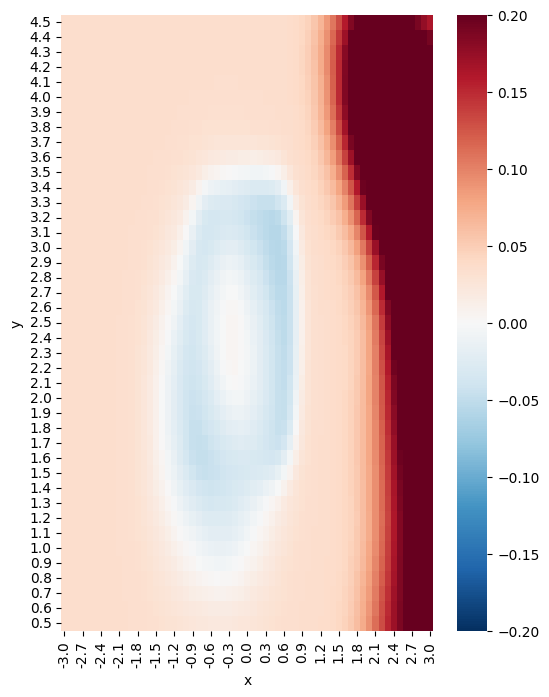

In [70]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

df = pd.DataFrame({'x': xs, 'y': zs, 'z': pitch_values})
pivot_table = df.pivot(index='y', columns='x', values='z')
plt.figure(figsize=(6, 8))
ax = sns.heatmap(
        pivot_table, 
        fmt='.0f',
        cmap='RdBu_r',
        vmin=-0.20,
        vmax=0.20,
        linecolor='none', 
        linewidths=0.5,
    )

ax.invert_yaxis()